<a href="https://colab.research.google.com/github/tamyressilvazz/machine-learning-p01/blob/main/projeto_final_tbs5_rls10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Grupo:** Rennan Lino Santos, Tamyres Bezerra da Silva

**Item 1. Escolha uma base de dados (por exemplo do repositório UCI) de um problema de classificação ou regressão. Apresente o problema de forma suscinta, com suas variáveis
preditoras e alvo.**


## Variável alvo

A variável alvo é **`num`**, que indica a presença de doença cardíaca.

Originalmente os valores são:

| Valor | Significado |
|------|-------------|
| 0 | Ausência de doença cardíaca |
| 1–4 | Presença de doença cardíaca |

Para simplificar o problema de classificação, os valores foram convertidos para **classificação binária**:

- **0 → sem doença cardíaca**
- **1 → presença de doença cardíaca**

---

## Variáveis preditoras

O conjunto de dados possui diversas variáveis que representam características clínicas dos pacientes.

Principais variáveis utilizadas como **preditoras**:

| Variável | Descrição |
|------|------|
| age | idade do paciente |
| sex | sexo |
| cp | tipo de dor no peito |
| trestbps | pressão arterial em repouso |
| chol | nível de colesterol |
| fbs | açúcar no sangue em jejum |
| restecg | resultados do eletrocardiograma |
| thalach | frequência cardíaca máxima |
| exang | angina induzida por exercício |
| oldpeak | depressão do segmento ST |
| slope | inclinação do segmento ST |
| ca | número de vasos principais |
| thal | resultado do teste de talassemia |

Essas variáveis são utilizadas pelo modelo para identificar padrões associados à presença de doença cardíaca.

**Item 2. Aplique o algoritmo de árvores de decisão e inspecione o conhecimento adquirido. Vc pode por exemplo selecionar a partir da árvore construída, regras com boa cobertura e confiança e discuti-las.**

**Carregar os dados**

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
car_evaluation = fetch_ucirepo(id=19)

# data (as pandas dataframes)
X = car_evaluation.data.features
y = car_evaluation.data.targets

# variable information
print(car_evaluation.variables)


{'uci_id': 19, 'name': 'Car Evaluation', 'repository_url': 'https://archive.ics.uci.edu/dataset/19/car+evaluation', 'data_url': 'https://archive.ics.uci.edu/static/public/19/data.csv', 'abstract': 'Derived from simple hierarchical decision model, this database may be useful for testing constructive induction and structure discovery methods.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1728, 'num_features': 6, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1988, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5JP48', 'creators': ['Marko Bohanec'], 'intro_paper': {'ID': 249, 'type': 'NATIVE', 'title': 'Knowledge acquisition and explanation for multi-attribute decision making', 'authors': 'M. Bohanec, V. Rajkovič', 'venue': '8th Intl Workshop on Expert Systems and their Applications, 

**Transformar o alvo em classificação binária**

In [ ]:
# limpar dados
X = X.replace("?", pd.NA)
X = X.apply(pd.to_numeric)

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [ ]:
y = y['num']
y = (y > 0).astype(int)
print(y)

0      0
1      1
2      1
3      0
4      0
      ..
298    1
299    1
300    1
301    1
302    0
Name: num, Length: 303, dtype: int64


**Dividir treino e teste**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Treinamento da árvore de decisão**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

**Avaliação do modelo**

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = tree.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print("Acurácia:", accuracy_score(y_test, y_pred))
print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred))

Acurácia: 0.8688524590163934
Matriz de confusão:
[[26  3]
 [ 5 27]]


**Matriz de confusão**

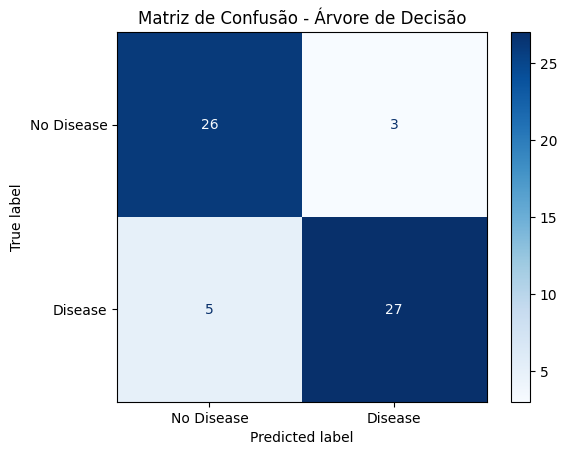

In [ ]:
# plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Disease"])
disp.plot(cmap="Blues", values_format="d")

plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

**Visualização da árvore**

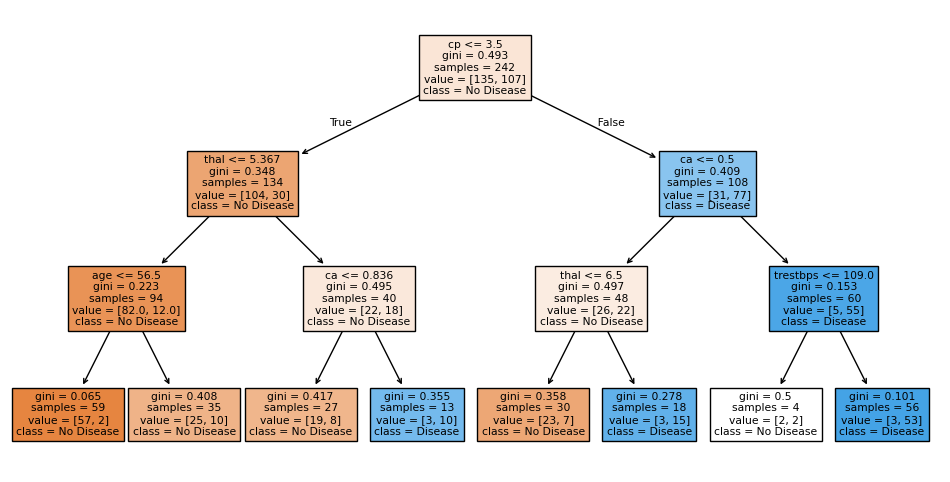

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 6))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["No Disease","Disease"],
    filled=True
)

plt.show()

**Extração de regras da árvore**

In [ ]:
from sklearn.tree import export_text
import pandas as pd

rules = export_text(tree, feature_names=list(X.columns))

# separa as linhas das regras
rules_list = rules.split("\n")

# cria tabela
rules_df = pd.DataFrame({
    "Regra da Árvore": rules_list
})

rules_df

,Regra da Árvore
0,|--- cp <= 3.50
1,| |--- thal <= 5.37
2,| | |--- age <= 56.50
3,| | | |--- class: 0
4,| | |--- age > 56.50
5,| | | |--- class: 0
6,| |--- thal > 5.37
7,| | |--- ca <= 0.84
8,| | | |--- class: 0
9,| | |--- ca > 0.84


**Importância das variáveis**

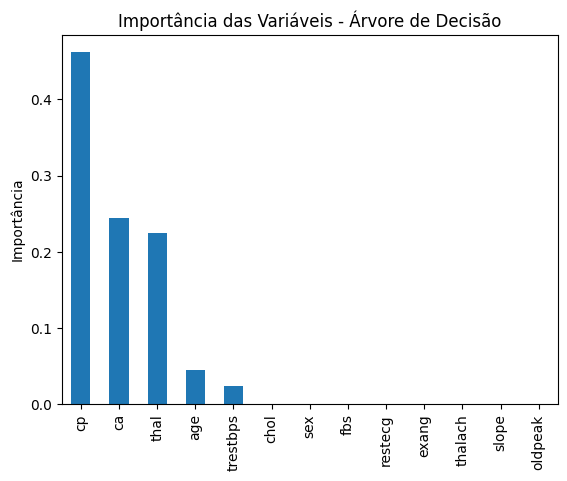

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(tree.feature_importances_, index=X.columns)

importances.sort_values(ascending=False).plot(kind="bar")

plt.title("Importância das Variáveis - Árvore de Decisão")
plt.ylabel("Importância")
plt.show()

**Item 3. Realize experimentos com algoritmos diversos e selecione o melhor algoritmo com base em uma métrica de avaliação de interesse. Justifique a escolha da métrica. Dependendo do algoritmo, faça experimentos com variação de parâmetros (e.g., valor do parâmetro k, do algoritmo kNN).**

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X = imputer.fit_transform(X)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# modelos
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "kNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc



In [ ]:

# mostrar resultados
import pandas as pd

results_df = pd.DataFrame(list(results.items()), columns=["Modelo", "Acurácia"])
results_df.sort_values(by="Acurácia", ascending=False)

,Modelo,Acurácia
2,kNN (k=5),0.918033
3,SVM,0.901639
1,Random Forest,0.901639
4,Logistic Regression,0.885246
0,Decision Tree,0.737705


In [ ]:
k_values = [1, 3, 5, 7, 9, 11]
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    knn_results.append((k, acc))

knn_df = pd.DataFrame(knn_results, columns=["k", "Acurácia"])
knn_df

,k,Acurácia
0,1,0.885246
1,3,0.934426
2,5,0.918033
3,7,0.868852
4,9,0.852459
5,11,0.885246


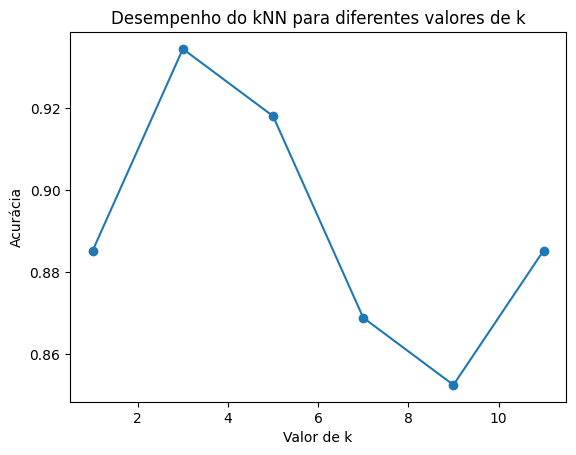

In [ ]:
import matplotlib.pyplot as plt

plt.plot(knn_df["k"], knn_df["Acurácia"], marker='o')
plt.xlabel("Valor de k")
plt.ylabel("Acurácia")
plt.title("Desempenho do kNN para diferentes valores de k")
plt.show()

**eleção de atributos**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# modelo com todos os atributos
knn_all = KNeighborsClassifier(n_neighbors=5)

knn_all.fit(X_train, y_train)
y_pred_all = knn_all.predict(X_test)

acc_all = accuracy_score(y_test, y_pred_all)

print("Acurácia (todos os atributos):", acc_all)

Acurácia (todos os atributos): 0.9180327868852459


In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# selecionar os 5 melhores atributos (pode testar outros valores)
selector = SelectKBest(score_func=mutual_info_classif, k=5)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

In [ ]:
selected_features = X.columns[selector.get_support()]

print("Atributos selecionados:")
print(selected_features)

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [ ]:
knn_selected = KNeighborsClassifier(n_neighbors=5)

knn_selected.fit(X_train_selected, y_train)
y_pred_selected = knn_selected.predict(X_test_selected)

acc_selected = accuracy_score(y_test, y_pred_selected)

print("Acurácia (atributos selecionados):", acc_selected)

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Modelo": ["kNN (todos atributos)", "kNN (atributos selecionados)"],
    "Acurácia": [acc_all, acc_selected]
})

comparison

In [ ]:
for k in [3, 5, 7, 9]:
    selector = SelectKBest(mutual_info_classif, k=k)
    X_train_sel = selector.fit_transform(X_train, y_train)
    X_test_sel = selector.transform(X_test)

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_sel, y_train)

    acc = accuracy_score(y_test, knn.predict(X_test_sel))
    print(f"k={k} -> Acurácia: {acc}")

In [ ]:
scores = selector.scores_

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": scores
}).sort_values(by="Score", ascending=False)

feature_scores